In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.interpolate as interp

In [2]:
import numpy as np
from scipy.integrate import odeint

class model_independent:
    def __init__(self,c,a,h0=0.6898,om=0.29044350092105475) :
        self.a = a
        self.da = (1-a[0])/a[0]
        self.x = (a-a[0])/(a[-1]-a[0])
        self.h0=h0
        self.om = om
        self.c = c
        self.norm = self._compute_norm()
        self.amin = self.a[0]
        self.amax = self.a[-1]
    
    def _compute_norm(self) :
        expf = self.da/(1+self.da*self.x)**2/self.chebs(self.c,2*self.x-1)/self.h0
        return expf[-1]

    def chebs (self,c,a) :
        if np.ndim(a) == 0 : # Needed for odeint, for some reason it asigns values outside boundaries
            if a>1 :
                a=1.0
            elif  a<-1 :
                a=-1.0
        x = np.arccos(a)
        result = 0
        for i in range(len(c)) :
            if i ==0 :
                result += (1/np.pi)**(1/2)*c[i]
            else :
                result += (2/np.pi)**(1/2)*c[i]*np.cos(i*x)
        return result
    
    def cheb_recursive(c,x) :
        n = len(c)
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        result = 0
        for i in range(len(c)) :
            result += c[i]*t[i]
        return result
    
    def cheb(self,n,x) :
        n = n+1 # For n-th polynomial, we need n+1 eements because the polynomial starts from 0
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        if n == 1 :
            t[0] = (1/np.pi)**(1/2)
            return t[0]
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        return t[n-1]
    
    
    def cheb_derivative(self,c,x) :
        n=len(c)
        x=np.atleast_1d(x) # Needed for odeint
        q=np.zeros((n,x.shape[0]))
        t=np.zeros((n,x.shape[0]))
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        q[0]=0
        q[1]=(2/np.pi)**(1/2)
        for i in range(1,n-1) :
            q[i+1]=2*t[i] + 2*x*q[i] - q[i-1]
        result = 0
        for i in range(n) :
            result += c[i]*q[i]
        if result.shape[0] == 1 : # Needed for odeint
            result = result[0]
        return result
        
    def lcdm_expf (self) :
        omega_m = self.om
        omega_l = 1-omega_m
        expf = np.sqrt (omega_m/self.a**3 + omega_l)
        return expf
    
    def d_expansion_function_d_a_lcdm (self, a):
        return 0.5/(a**3*self.lcdm_expf (a))* \
            (-3.0*self.om/a)
        # return 0.5/(a**3*self.lcdm_expf (a))* \
        #     (-4.0*self.omega_r/a**2-3.0*self.omega_m/a-2.0*self.omega_c)
    
    def model_expf (self, a=None, c=None) :
        if c is None :
            c = self.c
        if a is not None : # Needed for odeint
            x = (a-self.amin)/(self.amax-self.amin)
        else :
            x = self.x
        expf = self.da/(1+self.da*x)**2/self.chebs(c,2*x-1)/self.h0
        expf = expf/self.norm
        return expf
    
    def d_expansion_function_d_a (self,a=None,c=None):
        if c is None :
            c = self.c
        if a is not None : # Needed for odeint
            x = (a-self.amin)/(self.amax-self.amin)
        else :
            x = self.x
        A = (1+x*self.da)
        prefactor = -self.da/self.h0/(self.a[-1]-self.a[0])/A**2/self.chebs(c,2*x-1)
        term1 = 2*self.da/A
        term2 = 2*self.cheb_derivative(c,2*x-1)/self.chebs(c,2*x-1)
        d_expf = prefactor*(term1 + term2)/self.norm
        return d_expf
    
    def model_pca(self,c=None) :
        if c is None :
            c = self.c
        expf = self.lcdm_expf() + self.chebs(c,2*self.x-1)
        return expf
    
    def fit_model_to_lcdm (self,model_init,learning_rate = 0.1,n=10) :
        y_hat = model_init
        y = self.lcdm_expf()
        loss = np.sum(1/2*(y-y_hat)**2)
        print(loss)
        grad = np.zeros(len(self.c))
        grad_y = np.zeros((len(self.c),self.x.shape[0]))
        
        for i in range(0,n+1) :
            for j in range(0,len(self.c)) :
                grad_y[j] = -self.da/self.h0 * self.cheb(j,2*self.x-1)/(1+self.da*self.x)**2/self.chebs(self.c,2*self.x-1)**2
                grad[j] = np.sum((y_hat-y)*grad_y[j])

            self.c = self.c - learning_rate*grad
            self.norm = self._compute_norm()
            y_hat = self.model_expf()
            loss = np.sum(1/2*(y-y_hat)**2)
            if i == 0 or i%1000==0:
                print(f"iteration {i} ",loss)

    def fit_model_to_lcdm_pca (self,model_init,learning_rate = 0.1,n=10) :
        y = self.lcdm_expf()
        y_hat = model_init
        loss = np.sum(1/2*(y-y_hat)**2)
        print(loss)
        grad = np.zeros(len(self.c))
        grad_y = np.zeros((len(self.c),self.x.shape[0]))
        
        for i in range(0,n+1) :
            for j in range(0,len(self.c)) :
                grad_y[j] = self.cheb(j,2*self.x-1)
                grad[j] = np.sum((y_hat-y)*grad_y[j])

            self.c = self.c - learning_rate*grad
            self.norm = self._compute_norm()
            y_hat = self.model_pca()
            loss = np.sum(1/2*(y-y_hat)**2)
            if i == 0 or i%1000==0:
                print(f"iteration {i} ",loss)
                print(f"c : {self.c} \n")
    
class Growth_Factor :
    def __init__(self,c,a,h0=0.6898,om=0.29044350092105475):
        self.c = c
        self.a = a
        self.amin = self.a[0]
        self.amax = self.a[-1]
        self.model = model_independent(self.c,self.a,h0,om)
        self.n_growth = self.growth_index ()
        self.normalize()
    
    def growth_index (self):
        e0 = self.model.model_expf (a=self.amin)
        v = [ \
             3.0+2.0*self.amin* \
             self.model.d_expansion_function_d_a (a=self.amin)/e0, \
             1.0-self.model.om/(self.amin*(e0*self.amin)**2) \
            ]
        return 0.25*(-1.0-v[0]+np.sqrt ((1.0+v[0])**2+24.0*(1.0-v[1])))
    
    def normalize (self):
        self.D_plus_0 = 1.0
        self.D_plus_0 = self.growth_factor (1.0)

    def omega_matter (self, a):
        return self.model.om/(a**3*self.model.model_expf (a=a)**2)
    
    def growth_factor (self, a, n = 0):
        t = [self.amin, a]
        delta_initial = \
            [self.amin, self.n_growth*self.amin**(self.n_growth-1.0)]
        delta = odeint (self.growth_equation, delta_initial, t)
        return delta[1,n]
    
    def growth_equation (self, delta, a):
        c = [ \
             1.5*self.omega_matter (a)/a**2, \
             3.0/a+self.model.d_expansion_function_d_a (a=a)/ \
             self.model.model_expf (a=a) \
            ]
        return [delta[1], c[0]*delta[0]-c[1]*delta[1]]
    
    def D_plus (self, a):
        return self.growth_factor (a)/self.D_plus_0

617.540547321131
iteration 0  565.2938766884176
iteration 1000  0.43453471624518875
iteration 2000  0.40458215721390084
iteration 3000  0.4105410124143679
iteration 4000  0.40987255732900063
iteration 5000  0.41228056574687383
iteration 6000  0.4143320529475791
iteration 7000  0.4147836315450629
iteration 8000  0.4145708233579215
iteration 9000  0.4143484593228621
iteration 10000  0.4142460221560161
[ 0.90125145 -0.42186272  0.10139695 -0.06361757]


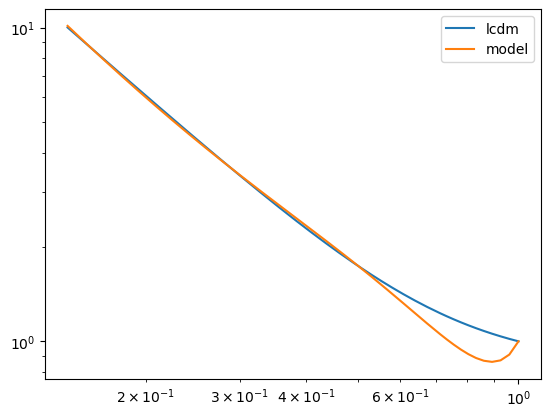

In [3]:
## Fitting model expansion function to LCDM

c = np.array([0.944, -0.357, 0.047,0])
a = np.loadtxt("a_bg.txt")
# a = np.linspace(0.294118,1.0,200)
me = model_independent(c,a,h0=0.6898,om=0.29044350092105475)

model = me.model_expf(c=c)
lcdm = me.lcdm_expf()

me.fit_model_to_lcdm(model,learning_rate=0.000003,n=10000)
print(me.c)
plt.loglog(a,lcdm,label="lcdm")
plt.loglog(a,me.model_expf(),label="model")
plt.legend()

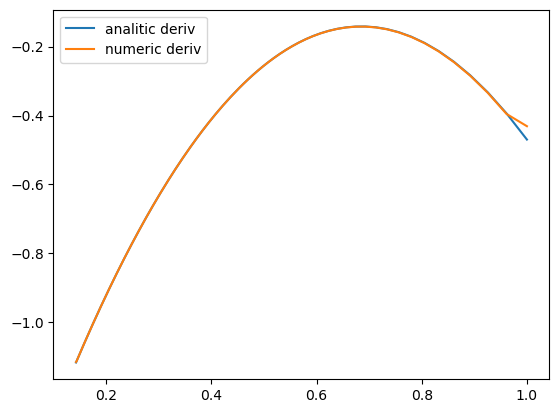

In [4]:
## Testing the implementation of the derivative of chebyshev polynomials

analitic = me.cheb_derivative(me.c,2*me.x-1)
numeric = np.gradient(me.chebs(me.c,2*me.x-1),2*me.x-1)
plt.plot(a,analitic,label='analitic deriv')
plt.plot(a,numeric,label='numeric deriv')
plt.legend()

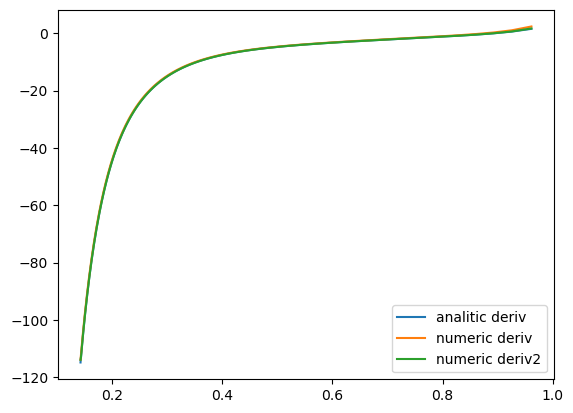

In [5]:
## Testing  the implementation of the derivative of the expansion function

analitic = me.d_expansion_function_d_a()
numeric1 = np.diff(me.model_expf())/np.diff(a)
numeric2 = np.gradient(me.model_expf(),me.a)
expf = me.model_expf()
# plt.loglog(me.a,expf,label='model expf')
# plt.loglog(me.a,me.lcdm_expf(),label='lcdm expf')
plt.plot(a[:-1],analitic[:-1],label='analitic deriv')
plt.plot(a[:-1],numeric1,label='numeric deriv')
plt.plot(a[:-1],numeric2[:-1],label='numeric deriv2')
plt.legend()

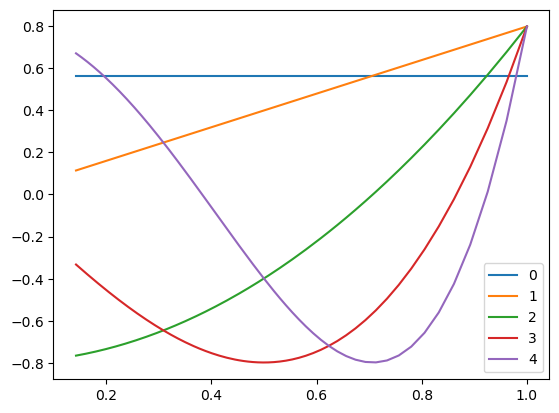

In [6]:
## Plotting the shape of n-th order chebyshev polynomial

for i in range(5) :
    plt.plot(a,me.cheb(i,a),label=f"{i}")
plt.legend()

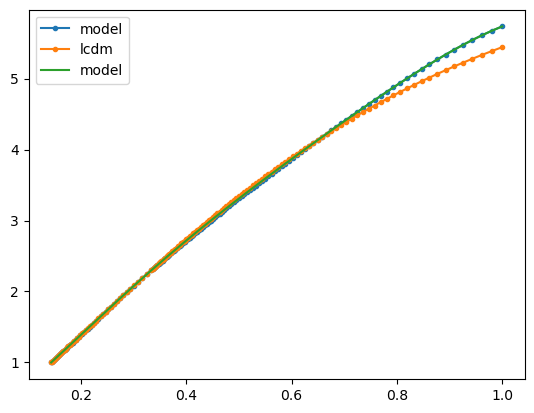

In [7]:
## Testing the implementation of Growth Factor

zm = np.loadtxt("z_matterme.txt")
am = 1/(1+zm)[::-1]
dplus = Growth_Factor(me.c,am,h0=0.6898,om=0.29044350092105475)
dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
dpl_kids = dpl_kids/dpl_kids[0]
Dplus = []
Dpluss = []

for i in dplus.a :
    Dplus.append(dplus.growth_factor(i))
    Dpluss.append(dplus.D_plus(i))
Dpluss = np.array(Dpluss)
Dpluss = Dpluss/Dpluss[0]
Dplus = np.array(Dplus)
Dplus = Dplus/Dplus[0]
plt.plot(dplus.a,Dplus,label='model',marker='.')
plt.plot(dplus.a,dpl_kids,label='lcdm',marker='.')
plt.plot(dplus.a,Dpluss,label='model')
plt.legend()
# plt.plot(a,)

difference from chain (grad_des, like : -49.82680775609994) : 1.2566157407219947e-08
difference from lcdm 60 (grad_des, like : -49.82680775609994) : 9.564538007841404e-09
difference from chain (best like : -48.091703978398) : 9.515276571162245e-09
difference from lcdm 60 (best like : -48.091703978398) : 9.564538007841404e-09
difference from chain (worst like : -182924.87667928817) : 3.0429130694189963e-06
difference from lcdm 60 (worst like : -182924.87667928817) : 9.564538007841404e-09
difference from chain (good like : -47.39) : 9.803273663502498e-09
difference from lcdm 60 (good like : -47.39) : 9.564538007841404e-09


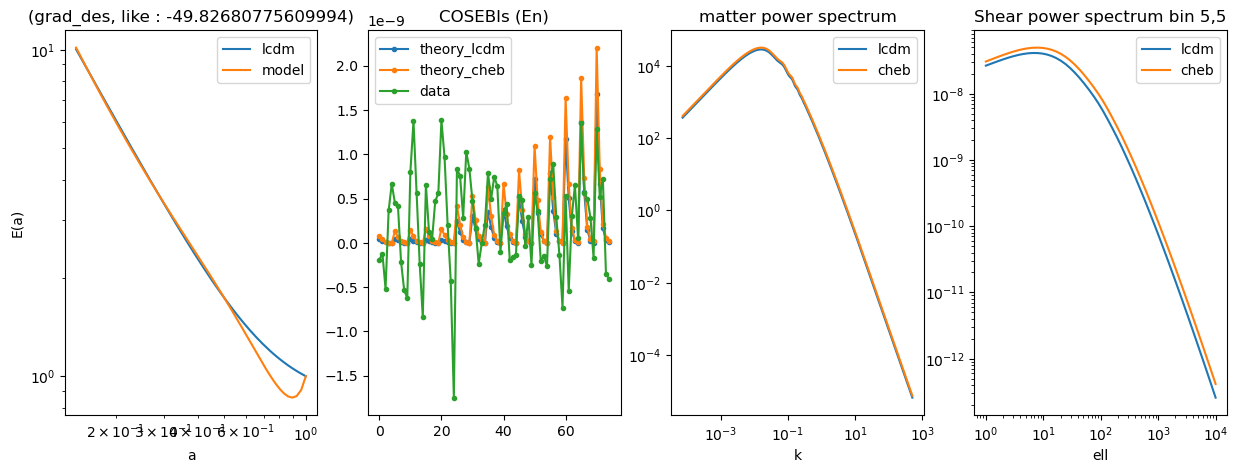

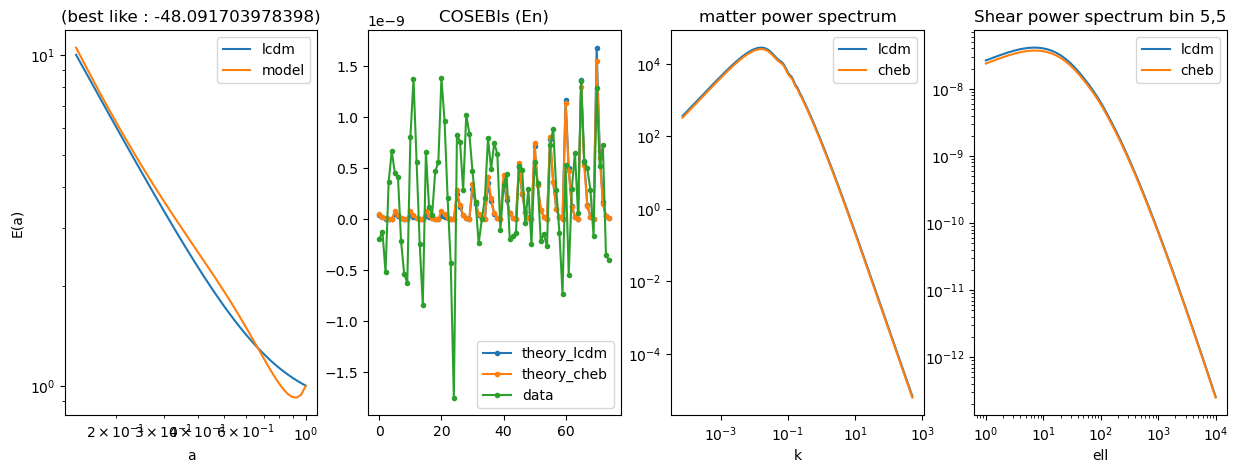

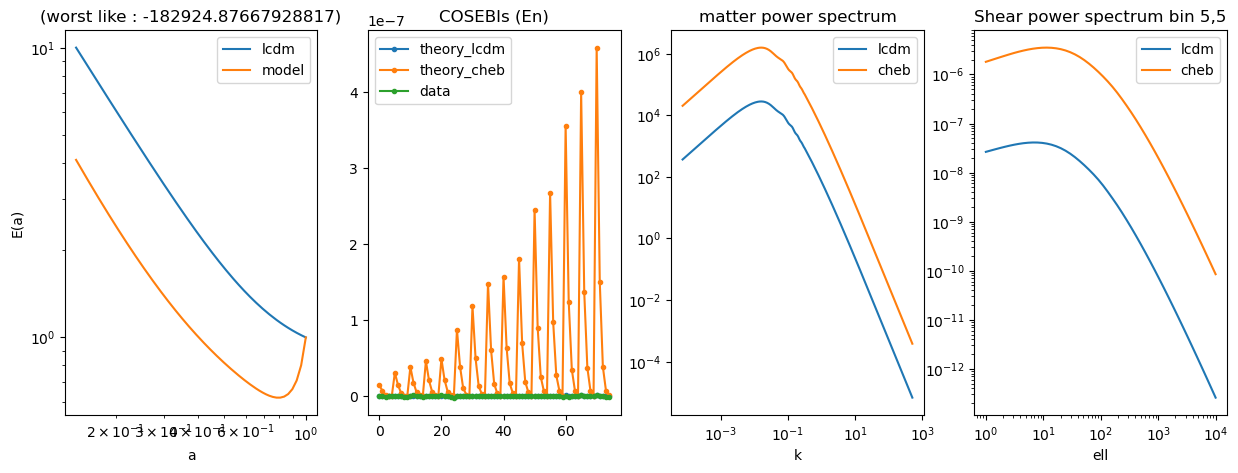

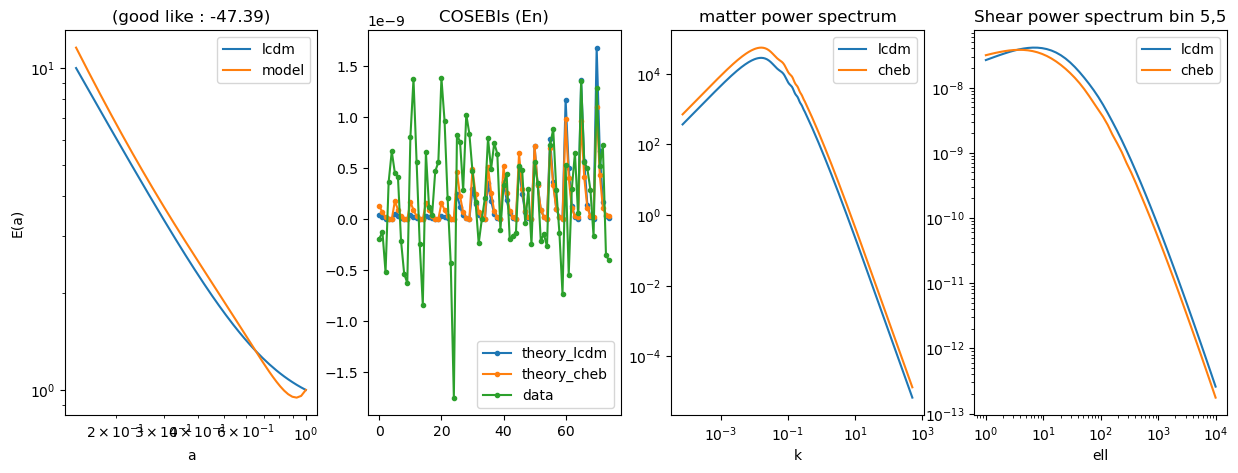

In [15]:
me = model_independent(c,a)
def combine(c,theory,pm,cell, comment="") :
    k = np.loadtxt("k_hme.txt")
    a = np.loadtxt("a_bg.txt")
    ells = np.loadtxt("ellsme.txt")
    pm_lcdm = np.loadtxt("pm_lin_60.txt")[0]
    cell_lcdm = np.loadtxt("c_ell_lin_60.txt")
    me = model_independent(c,a)
    model = me.model_expf()
    lcdm = me.lcdm_expf()
    plt.figure(figsize=(15,5))
    plt.subplot(1,4,1)
    plt.loglog(a,lcdm,label="lcdm")
    plt.loglog(a,model,label="model")
    # plt.xlim(0.5,1)
    plt.ylabel("E(a)")
    plt.xlabel("a")
    plt.title(comment)
    plt.legend()

    dt60 = np.loadtxt("data-theory_data60_theory60.txt")
    diff_best_like = np.abs(theory-dt60[:,0])
    diff_lcdm_60 = np.abs(dt60[:,1]-dt60[:,0])
    n=40
    print("difference from chain", comment, ":", np.sum(diff_best_like[n:]))
    print("difference from lcdm 60", comment, ":" , np.sum(diff_lcdm_60[n:]))
    plt.subplot(1,4,2)
    plt.plot(dt60[:,1],label="theory_lcdm",marker = '.')
    plt.plot(theory, label = "theory_cheb",marker='.')
    plt.plot(dt60[:,0], label = "data",marker = '.')
    plt.title("COSEBIs (En)")
    plt.legend();

    plt.subplot(1,4,3)
    plt.loglog(k,pm_lcdm,label="lcdm")
    plt.loglog(k,pm,label="cheb")
    plt.legend();
    plt.xlabel('k')
    plt.title("matter power spectrum")

    plt.subplot(1,4,4)
    plt.loglog(ells,cell_lcdm,label="lcdm")
    plt.loglog(ells,cell,label="cheb")
    plt.legend();
    plt.xlabel('ell')
    plt.title("Shear power spectrum bin 5,5")

c = np.array([0.90125145, -0.42186272,  0.10139695, -0.06361757])
theory = np.loadtxt("data-theory_grad_des_new.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_grad_des_new.txt")[0]
cell = np.loadtxt("c_ell_grad_des_new.txt")
combine(c,theory,pm,cell,"(grad_des, like : -49.82680775609994)")

c = np.array([0.9853482478718526,	-0.469695954390673,	0.13763057859793937,-0.06950337725419585])
theory_best_like = np.loadtxt("data-theory_best_like_new.txt", skiprows=1)[:,1]
pm = np.loadtxt("pm_best_like_new.txt")[0]
cell = np.loadtxt("c_ell_best_like_new.txt")
combine(c,theory_best_like,pm,cell,"(best like : -48.091703978398)")

c = np.array([1.0320677375793457,-0.6950483950972557,0.1575472903251648,-0.05516065055131912])
theory = np.loadtxt("data-theory_chain3.txt",skiprows=1)[:,1] # like = -967548.2720155459
pm = np.loadtxt("pm_worst_like_new.txt")[0]
cell = np.loadtxt("c_ell_worst_like_new.txt")
combine(c,theory,pm,cell,"(worst like : -182924.87667928817)")

c = np.array([1.3676562761732827,	-0.6177352519042305,	0.14366336161970764,	-0.06795405255128631])
theory = np.loadtxt("data-theory_chain2.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_chain2.txt")[0]
cell = np.loadtxt("c_ell_chain2.txt")
combine(c,theory,pm,cell,"(good like : -47.39)")